# Where in the midlatitudes is the summer threshold above that for "cooling degree days"?

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [4]:
# get baseline
file_path = '../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75


<xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 8MB
[1038240 values with dtype=float64]
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

In [6]:
# define threshold for a cooling degree day
cdd_thresh = 273.15+18.3

In [15]:
#c_75.lat >= 23.5
c_75_midlat = c_75.where((c_75.lat >= 23.5) | (c_75.lat <= -23.5))
c_75_midlat

<xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 8MB
array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]], shape=(721, 1440))
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

# plot those above the threshold for cooling degree days

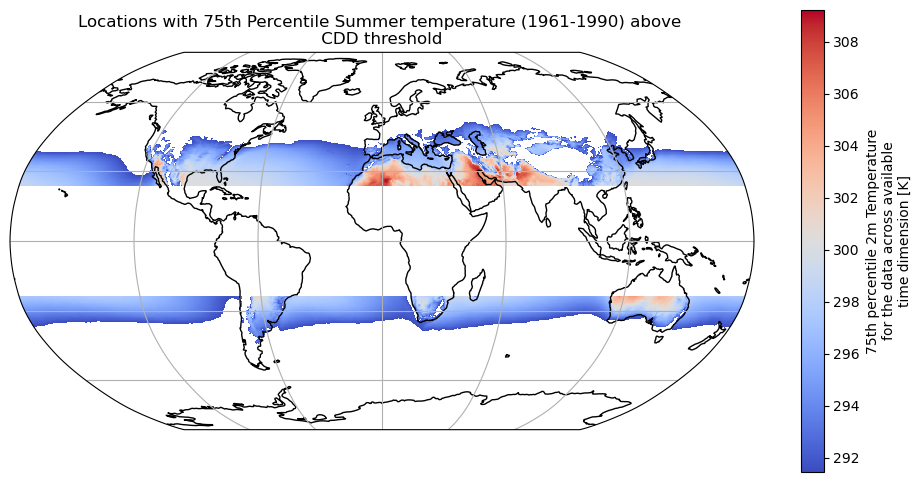

In [16]:
# plots for the year
##############
# Global summer mean temp for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

c_75_midlat.where((c_75_midlat.values >= cdd_thresh)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=250,
    #vmax=320, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Locations with 75th Percentile Summer temperature (1961-1990) above \n CDD threshold ")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

